In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [222]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### **EDA**

In [223]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [225]:
df.shape

(1338, 7)

In [226]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [227]:
x = df.drop("charges", axis=1)
y = df["charges"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### **Features Encoding**

In [228]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

In [229]:
x_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False


### **Features Scaling**

In [230]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [231]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [232]:
x_train_scaled[0:5]

array([[ 0.47222651, -1.75652513,  0.73433626, -1.0246016 , -0.50874702,
         1.78316783, -0.59966106, -0.5723141 ],
       [ 0.54331294, -1.03308239, -0.91119211, -1.0246016 , -0.50874702,
        -0.56079971, -0.59966106, -0.5723141 ],
       [ 0.8987451 , -0.94368672, -0.91119211, -1.0246016 , -0.50874702,
        -0.56079971,  1.66760869, -0.5723141 ],
       [-0.02537852,  0.62239299,  3.20262882, -1.0246016 , -0.50874702,
        -0.56079971,  1.66760869, -0.5723141 ],
       [ 1.04091797, -1.50489287,  1.55710045, -1.0246016 , -0.50874702,
         1.78316783, -0.59966106, -0.5723141 ]])

### **Model Training**

In [233]:
linear = LinearRegression()
lasso = Lasso(alpha=6.2)
ridge = Ridge(alpha=2)

In [234]:
# Linear Regression
linear.fit(x_train_scaled, y_train)

LinearRegression()

In [235]:
#Lasso Regression
lasso.fit(x_train_scaled, y_train)

Lasso(alpha=6.2)

In [236]:
#Ridge Regression
ridge.fit(x_train_scaled, y_train)

Ridge(alpha=2)

### **Model Evaluation**

In [237]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    def metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return mae, r2
    
    train_metrics = metrics(y_train, y_pred_train)
    test_metrics = metrics(y_test, y_pred_test)
    
    # Print
    print(f"📌 {name}")
    print("---- Train ----")
    print(f"MAE: {train_metrics[0]:.2f}")
    print(f"R2: {train_metrics[1]:.4f}")
    
    print("---- Test ----")
    print(f"MAE: {test_metrics[0]:.2f}")
    print(f"R2: {test_metrics[1]:.4f}")
    
    print("="*40)

In [238]:
evaluate_model("Linear Regression", linear, x_train_scaled, x_test_scaled, y_train, y_test)
evaluate_model("Ridge", ridge, x_train_scaled, x_test_scaled, y_train, y_test)
evaluate_model("Lasso", lasso, x_train_scaled, x_test_scaled, y_train, y_test)

📌 Linear Regression
---- Train ----
MAE: 4208.23
R2: 0.7417
---- Test ----
MAE: 4181.19
R2: 0.7836
📌 Ridge
---- Train ----
MAE: 4210.54
R2: 0.7417
---- Test ----
MAE: 4184.45
R2: 0.7835
📌 Lasso
---- Train ----
MAE: 4207.78
R2: 0.7417
---- Test ----
MAE: 4183.26
R2: 0.7834


In [239]:
print(lasso.coef_, "\n")  # no feature selection, all features are important
print(ridge.coef_, "\n")  
print(linear.coef_, "\n") 
# the difference between linear and ridge is not significant,cuz all features are important

[ 3.60958156e+03  2.02698984e+03  5.10912330e+02 -2.28065955e+00
  9.55167927e+03 -1.39151562e+02 -2.68227308e+02 -3.29221050e+02] 

[ 3.60774086e+03  2.03250091e+03  5.16632612e+02 -7.94144062e+00
  9.54008982e+03 -1.57130558e+02 -2.86942330e+02 -3.47435529e+02] 

[ 3.61497541e+03  2.03622812e+03  5.16890247e+02 -9.29310107e+00
  9.55848141e+03 -1.58140981e+02 -2.90157047e+02 -3.49110678e+02] 



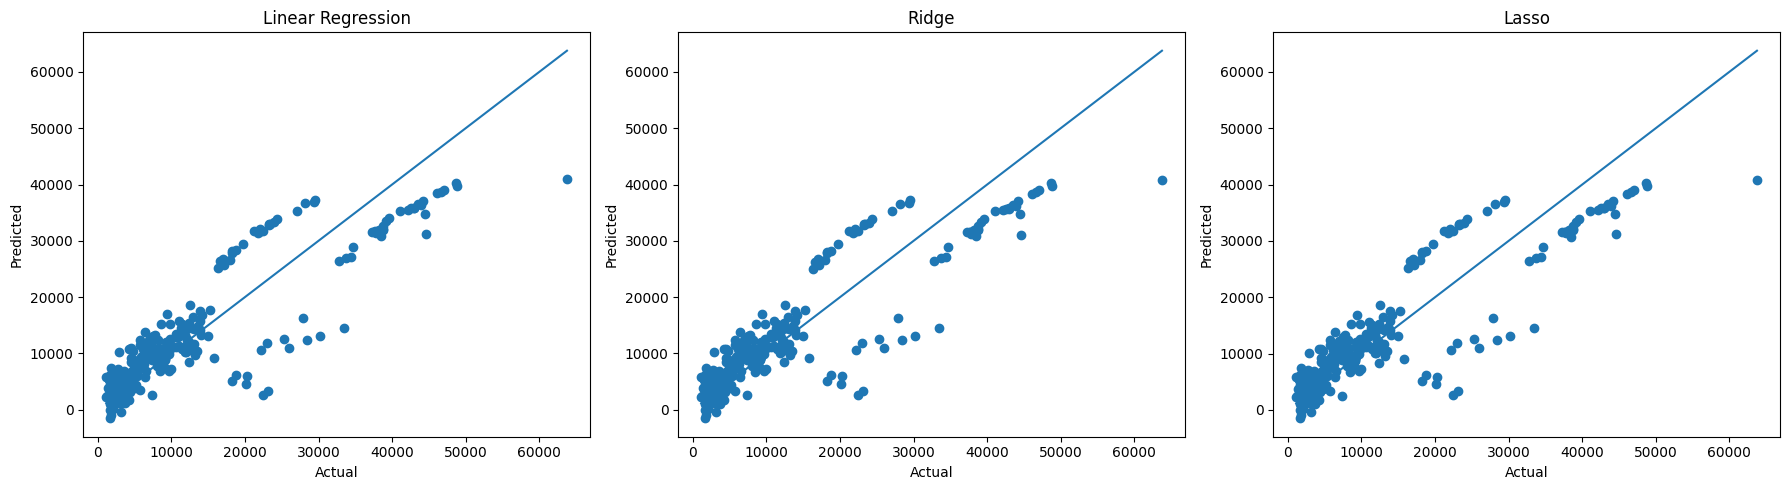

In [240]:
# predictions
y_pred_lr = linear.predict(x_test_scaled)
y_pred_ridge = ridge.predict(x_test_scaled)
y_pred_lasso = lasso.predict(x_test_scaled)

# figure
plt.figure(figsize=(18,5))

# Linear Regression
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Ridge
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_ridge)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Ridge")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Lasso
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_lasso)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Lasso")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()